# Preprocess functions demo + visualization
# Notebook: mỗi ô code định nghĩa 1 hàm tương ứng và có trực quan hoá để quan sát kết quả


In [12]:
%matplotlib inline

In [1]:
import matplotlib
print("backend:", matplotlib.get_backend())

backend: module://matplotlib_inline.backend_inline


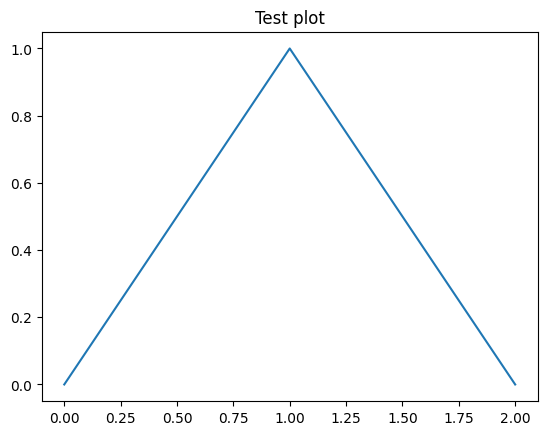

In [2]:
import matplotlib.pyplot as plt
plt.plot([0,1,2],[0,1,0])
plt.title("Test plot")
plt.show()

In [3]:
# 1. Setup: import libraries and helper loader
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# display settings
plt.rcParams['figure.figsize'] = (10,4)
sns.set(style='whitegrid')

# utility: robust CSV loader trying different metadata column counts
def robust_load_numeric(path, metadata_trials=(2,1,0)):
    path = Path(path)
    last_err = None
    for meta in metadata_trials:
        try:
            from src.amp_phase import load_numeric_csv
        except Exception:
            # fallback to pandas simple loader
            try:
                df = pd.read_csv(path, header=None)
                arr = df.values
                if arr.shape[1] > meta:
                    return arr[:, meta:]
            except Exception as e:
                last_err = e
                continue
        try:
            arr = load_numeric_csv(path, metadata_columns=meta)
            return arr
        except Exception as e:
            last_err = e
    raise last_err if last_err is not None else ValueError('Cannot load')

# try to find a sample CSV in repository (support running from `src/` by checking parent folder)
sample_candidates = [
    Path('../data/raw/yes_3.5.csv'),
    Path('../data/raw/sit.csv'),
    Path('../data/raw/stand.csv'),
    Path('../data/test/test.csv'),
    Path('../data/test/test1.csv'),
    Path('../data/test/test_sit.csv'),
]
SAMPLE_PATH = None
for p in sample_candidates:
    if p.exists():
        SAMPLE_PATH = p.resolve()
        break

print('Sample path:', SAMPLE_PATH)


Sample path: C:\esp32\csi\data\raw\yes_3.5.csv


Environment versions:
- numpy: 2.2.6
- pandas: 3.0.1
- matplotlib: 3.10.5
- seaborn: 0.13.2
- sklearn: 1.8.0


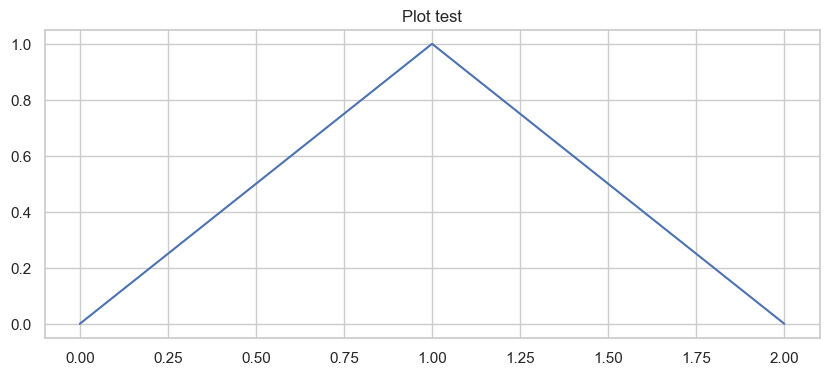

In [4]:
# 2. init_env(): kiểm tra phiên bản thư viện và trả về dict thông tin
import importlib

def init_env():
    libs = ['numpy','pandas','matplotlib','seaborn','sklearn']
    info = {}
    for lib in libs:
        try:
            m = importlib.import_module(lib)
            info[lib] = getattr(m, '__version__', 'unknown')
        except Exception as e:
            info[lib] = f'not installed: {e}'
    print('Environment versions:')
    for k,v in info.items():
        print(f"- {k}: {v}")
    # quick plot to ensure plotting works
    fig, ax = plt.subplots()
    ax.plot([0,1,2],[0,1,0])
    ax.set_title('Plot test')
    plt.show()
    return info

# run check
_env_info = init_env()


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


(511637, 63)


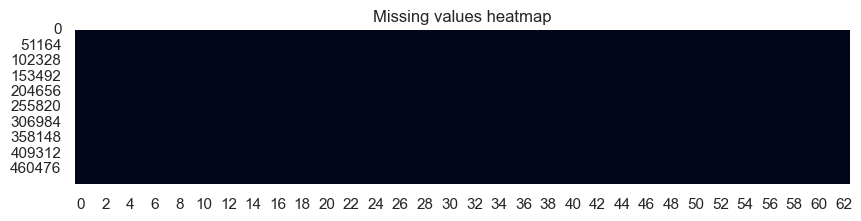

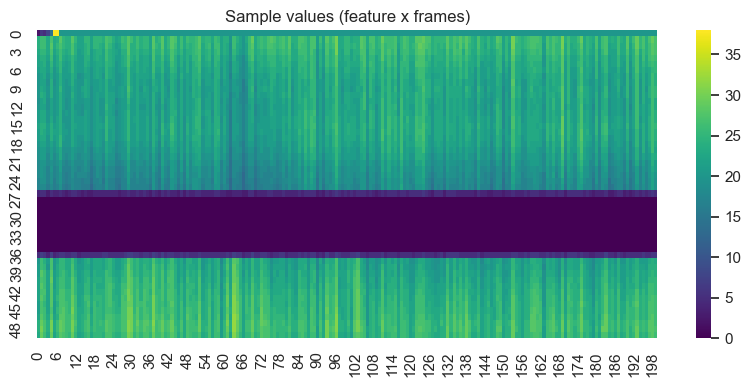

In [5]:
# load_data(path): nạp CSV vào DataFrame và trực quan hoá heatmap đơn giản
def load_data(path):
    from pathlib import Path
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(p)
    try:
        arr = robust_load_numeric(p)
        df = pd.DataFrame(arr)
    except Exception:
        df = pd.read_csv(p)
    display(df.head())
    print(df.shape)
    # missing heatmap
    plt.figure(figsize=(10,2))
    sns.heatmap(df.isnull(), cbar=False)
    plt.title('Missing values heatmap')
    plt.show()
    # value heatmap sample
    plt.figure(figsize=(10,4))
    sns.heatmap(df.iloc[:200, :min(50, df.shape[1])].T, cmap='viridis')
    plt.title('Sample values (feature x frames)')
    plt.show()
    return df

# auto-run if sample available
if SAMPLE_PATH is not None:
    try:
        df_sample = load_data(SAMPLE_PATH)
    except Exception as e:
        print('load_data failed:', e)


SAMPLE_PATH = C:\esp32\csi\data\raw\yes_3.5.csv
df_sample.shape = (511637, 63)
explore_data: df type= <class 'pandas.DataFrame'>
explore_data: df.shape= (511637, 63)


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
count,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,...,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.00000,511637.000000
mean,19.998808,25.838149,25.630023,25.029150,24.387593,23.944003,23.449903,22.868014,22.462926,22.531602,...,22.488260,22.123169,22.438205,22.786579,23.072553,23.452479,23.914955,24.936199,25.87765,26.160375
std,0.289030,3.866589,3.912769,3.904734,3.915298,3.972884,4.008664,4.041653,4.149668,4.442563,...,4.130821,3.899228,3.817840,3.753988,3.680032,3.633310,3.621946,3.693170,3.78714,3.839208
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,20.000000,24.000000,24.000000,23.000000,22.000000,22.000000,21.000000,21.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,21.000000,21.000000,22.000000,22.000000,23.000000,24.00000,24.000000
50%,20.000000,26.000000,26.000000,25.000000,25.000000,24.000000,24.000000,23.000000,23.000000,23.000000,...,23.000000,22.000000,23.000000,23.000000,23.000000,24.000000,24.000000,25.000000,26.00000,26.000000
75%,20.000000,28.000000,28.000000,27.000000,27.000000,26.000000,26.000000,25.000000,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,26.000000,26.000000,27.000000,28.00000,28.000000
max,38.000000,99.000000,101.000000,94.000000,92.000000,92.000000,89.000000,85.000000,88.000000,104.000000,...,86.000000,80.000000,84.000000,80.000000,81.000000,79.000000,85.000000,96.000000,94.00000,98.000000


Plotting hist for columns: [0, 1, 2, 3, 4, 5]


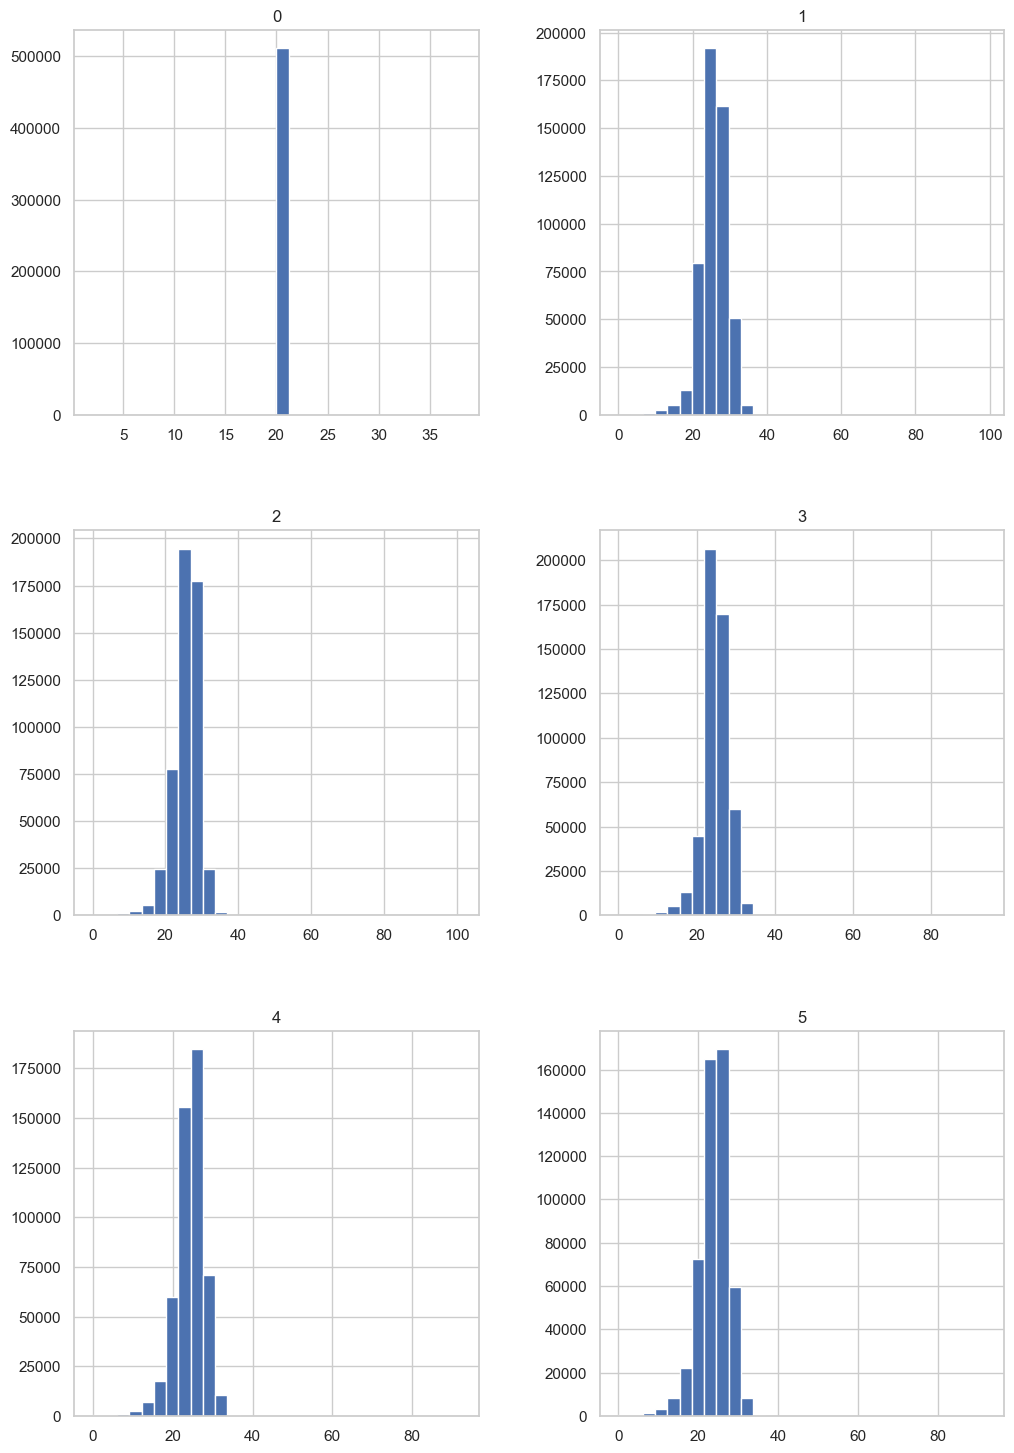

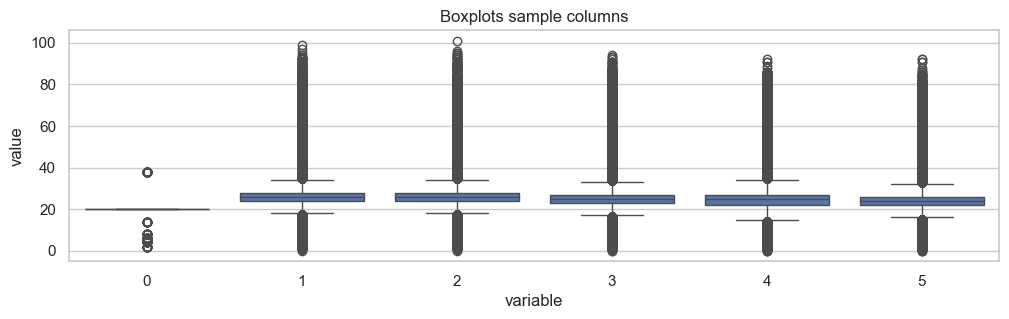

Numeric columns count: 63


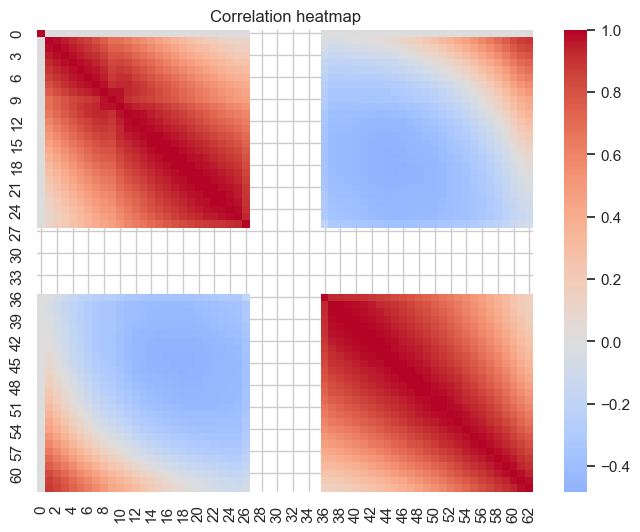

In [6]:
# explore_data(df): EDA cơ bản - histogram, boxplot, correlation heatmap
def explore_data(df, sample_cols=6):
    # Debug prints để biết vì sao không có output
    try:
        print('explore_data: df type=', type(df))
        print('explore_data: df.shape=', getattr(df, 'shape', None))
    except Exception as e:
        print('Error reading df meta:', e)
    if df is None:
        print('Input df is None')
        return
    if getattr(df, 'shape', (0,0))[0] == 0:
        print('Input df is empty')
        return

    try:
        display(df.describe())
    except Exception as e:
        print('describe() failed:', e)

    # histograms for first few columns
    cols = df.columns[:sample_cols]
    print('Plotting hist for columns:', list(cols))
    try:
        df[cols].astype(float).hist(bins=30, figsize=(12,3*len(cols)))
        plt.show()
    except Exception as e:
        print('Histogram plot failed:', e)
        # fallback: try numeric-only columns
        numcols = df.select_dtypes(include=[float, int]).columns[:sample_cols]
        if len(numcols) > 0:
            print('Trying numeric columns for hist:', list(numcols))
            df[numcols].hist(bins=30, figsize=(12,3*len(numcols)))
            plt.show()
        else:
            print('No numeric columns to plot histograms')

    # boxplots
    try:
        plt.figure(figsize=(12,3))
        sns.boxplot(data=df[cols].astype(float).melt(), x='variable', y='value')
        plt.title('Boxplots sample columns')
        plt.show()
    except Exception as e:
        print('Boxplot failed:', e)

    # correlation heatmap for numeric cols
    try:
        num = df.select_dtypes(include=[np.number])
        print('Numeric columns count:', num.shape[1])
        if num.shape[1] > 1:
            corr = num.corr()
            plt.figure(figsize=(8,6))
            sns.heatmap(corr, cmap='coolwarm', center=0)
            plt.title('Correlation heatmap')
            plt.show()
        else:
            print('Not enough numeric columns for correlation heatmap')
    except Exception as e:
        print('Correlation heatmap failed:', e)
# kiểm tra sample, load lại nếu cần, rồi gọi explore_data
print("SAMPLE_PATH =", SAMPLE_PATH)
if 'df_sample' not in globals() or df_sample is None:
    df_sample = load_data(SAMPLE_PATH)  # hoặc đặt path cụ thể
print("df_sample.shape =", getattr(df_sample, "shape", None))
explore_data(df_sample)


In [7]:
# impute_missing(df, strategy, cols=None): drop/mean/median/mode/ffill/bfill

def impute_missing(df, strategy='mean', cols=None):
    df = df.copy()
    if cols is None:
        cols = df.columns
    before = df[cols].isnull().sum()
    print('Missing before:')
    print(before)
    print('Total missing before:', int(before.sum()))
    if strategy == 'drop':
        df = df.dropna()
    elif strategy in ('mean','median'):
        for c in cols:
            if df[c].dtype.kind in 'biufc':
                val = df[c].mean() if strategy=='mean' else df[c].median()
                df[c] = df[c].fillna(val)
    elif strategy == 'mode':
        for c in cols:
            df[c] = df[c].fillna(df[c].mode().iloc[0] if not df[c].mode().empty else 0)
    elif strategy in ('ffill','bfill'):
        df[cols] = df[cols].fillna(method=strategy)
    else:
        raise ValueError('Unknown strategy')
    after = df[cols].isnull().sum()
    print('Missing after:')
    print(after)
    print('Total missing after:', int(after.sum()))
    if int(before.sum()) == 0 and int(after.sum()) == 0:
        print('No missing values detected in the provided columns')
    # bar plot comparison
    comp = pd.DataFrame({'before': before, 'after': after}).loc[cols]
    comp = comp[(comp['before']>0)|(comp['after']>0)]
    if not comp.empty:
        comp.plot.bar(figsize=(8,3))
        plt.title('Missing before/after per column')
        plt.show()
    else:
        print('No columns with missing values to plot')
    return df


In [8]:
# encode_categorical(df, method='onehot'|'label'|'target', cols=None)
from sklearn.preprocessing import LabelEncoder

def encode_categorical(df, method='onehot', cols=None):
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=['object','category']).columns.tolist()
    print('Encoding cols:', cols)
    if method=='onehot':
        df = pd.get_dummies(df, columns=cols, drop_first=True)
    elif method=='label':
        le = LabelEncoder()
        for c in cols:
            df[c] = le.fit_transform(df[c].astype(str))
    else:
        raise ValueError('Unsupported method in demo')
    # frequency plot for first encoded column
    if cols:
        col = cols[0]
        plt.figure(figsize=(6,3))
        df[col].value_counts().head(20).plot.bar()
        plt.title(f'Value counts after encoding: {col}')
        plt.show()
    return df


In [9]:
# scale_features(df, cols, method='standard'|'minmax'|'robust')
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

def scale_features(df, cols, method='standard'):
    df = df.copy()
    if isinstance(cols, str):
        cols = [cols]
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print('Scaling cols:', cols[:10])
    scaler = StandardScaler() if method=='standard' else MinMaxScaler() if method=='minmax' else RobustScaler()
    df[cols] = scaler.fit_transform(df[cols].astype(float))
    # plot hist before/after would require original; for demo we show scaled hist
    df[cols[:min(4,len(cols))]].hist(bins=30, figsize=(12,3))
    plt.suptitle(f'Scaled columns (method={method})')
    plt.show()
    return df, scaler


In [10]:
# handle_outliers(df, cols, method='iqr'|'zscore'|'clip')
def handle_outliers(df, cols=None, method='iqr'):
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for c in cols[:6]:
        series = df[c].astype(float)
        plt.figure(figsize=(6,2))
        sns.boxplot(x=series)
        plt.title(f'Before outlier handling: {c}')
        plt.show()
        if method=='iqr':
            q1 = series.quantile(0.25)
            q3 = series.quantile(0.75)
            iqr = q3-q1
            low = q1-1.5*iqr
            high = q3+1.5*iqr
            df[c] = series.clip(low, high)
        elif method=='zscore':
            mean = series.mean(); std = series.std()
            z = (series-mean)/std
            df[c] = series.where(z.abs()<=3, series.median())
        elif method=='clip':
            df[c] = series.clip(series.quantile(0.01), series.quantile(0.99))
        plt.figure(figsize=(6,2))
        sns.boxplot(x=df[c].astype(float))
        plt.title(f'After outlier handling: {c}')
        plt.show()
    return df


In [11]:
# feature_engineering(df): tạo vài feature demo và trực quan hoá so với giả sử target

def feature_engineering(df):
    df = df.copy()
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] >= 2:
        a = num.iloc[:,0]
        b = num.iloc[:,1]
        df['ratio_0_1'] = a / (b + 1e-8)
        df['sum_0_1'] = a + b
        plt.figure(figsize=(6,3))
        sns.scatterplot(x='ratio_0_1', y='sum_0_1', data=df.sample(min(1000, len(df))))
        plt.title('Feature interaction: ratio vs sum')
        plt.show()
    else:
        print('Not enough numeric cols for demo')
    return df


In [12]:
# select_features(df, target=None, method='variance')
from sklearn.feature_selection import SelectKBest, f_classif

def select_features(df, target=None, method='variance', k=10):
    num = df.select_dtypes(include=[np.number])
    if method=='variance':
        variances = num.var().sort_values(ascending=False)
        sel = variances.index[:k].tolist()
        plt.figure(figsize=(8,3))
        variances.head(k).plot.bar()
        plt.title('Top variances')
        plt.show()
        return sel
    elif method=='kbest' and target is not None:
        y = df[target]
        X = num
        skb = SelectKBest(f_classif, k=k).fit(X, y)
        scores = pd.Series(skb.scores_, index=X.columns).sort_values(ascending=False)
        scores.head(k).plot.bar(figsize=(8,3))
        plt.title('KBest scores')
        plt.show()
        return scores.index[:k].tolist()
    else:
        raise ValueError('Unsupported method or missing target')


In [13]:
# split_and_save(df, target, test_size=0.2, out_dir='experiments/preprocessed')
from sklearn.model_selection import train_test_split

def split_and_save(df, target=None, test_size=0.2, out_dir='experiments/preprocessed'):
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)
    if target is None or target not in df.columns:
        # just random split
        train, test = train_test_split(df, test_size=test_size)
    else:
        train, test = train_test_split(df, test_size=test_size, stratify=df[target])
    train_path = out / 'train.csv'
    test_path = out / 'test.csv'
    train.to_csv(train_path, index=False)
    test.to_csv(test_path, index=False)
    print('Saved:', train_path, test_path)
    # class balance plot if target present
    if target in df.columns:
        plt.figure(figsize=(8,3))
        sns.countplot(x=target, data=train)
        plt.title('Train class balance')
        plt.show()
        plt.figure(figsize=(8,3))
        sns.countplot(x=target, data=test)
        plt.title('Test class balance')
        plt.show()
    return train_path, test_path


In [14]:
# save_pipeline / load_pipeline demo using joblib
import joblib

def save_pipeline(pipeline, path):
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(pipeline, p)
    print('Saved pipeline to', p)

def load_pipeline(path):
    p = Path(path)
    return joblib.load(p)

# demo apply (if scaler exists)


In [15]:
# run_full_preprocessing(config) - demo orchestration

def run_full_preprocessing(path=None):
    if path is None:
        path = SAMPLE_PATH
    if path is None:
        print('No sample provided')
        return
    df = load_data(path)
    explore_data(df)
    df2 = impute_missing(df, strategy='mean')
    df3 = feature_engineering(df2)
    sel = select_features(df3, method='variance', k=6)
    print('Selected features:', sel)
    scaled, scaler = scale_features(df3, cols=sel, method='standard')
    save_pipeline({'scaler':scaler}, 'experiments/preprocessed/pipeline.joblib')
    split_and_save(scaled)
    print('Full pipeline run completed')


# Summary

print('Notebook tạo các hàm tiền xử lý và trực quan hoá.'):

SAMPLE_PATH = C:\esp32\csi\data\raw\yes_3.5.csv


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


(511637, 63)


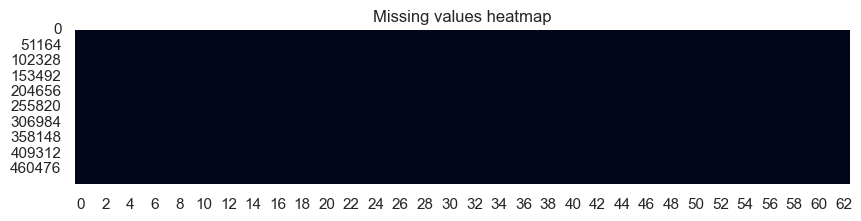

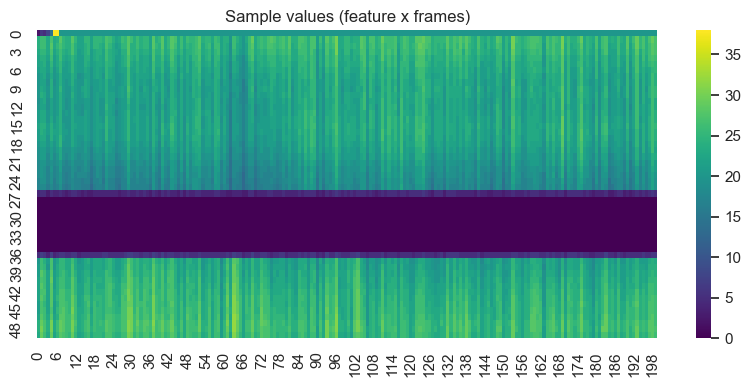

Loaded shape: (511637, 63)


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


Total missing in df_sample (before): 0
Missing before:
0     0
1     0
2     0
3     0
4     0
     ..
58    0
59    0
60    0
61    0
62    0
Length: 63, dtype: int64
Total missing before: 0
Missing after:
0     0
1     0
2     0
3     0
4     0
     ..
58    0
59    0
60    0
61    0
62    0
Length: 63, dtype: int64
Total missing after: 0
No missing values detected in the provided columns
No columns with missing values to plot
Total missing after impute_missing: 0


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


In [16]:
# Debug / run thử
print("SAMPLE_PATH =", SAMPLE_PATH)
if SAMPLE_PATH is None:
    SAMPLE_PATH = "data/test/test.csv"   # hoặc đặt đường dẫn CSV của bạn
    print("Set SAMPLE_PATH to", SAMPLE_PATH)

try:
    df_sample = load_data(SAMPLE_PATH)
    print("Loaded shape:", df_sample.shape)
    display(df_sample.head())
    print('Total missing in df_sample (before):', int(df_sample.isnull().sum().sum()))
    # call impute_missing and show results
    df2 = impute_missing(df_sample, strategy='mean')
    print('Total missing after impute_missing:', int(df2.isnull().sum().sum()))
    display(df2.head())
except Exception as e:
    print("load_data/impute_missing raised:", repr(e))


matplotlib backend: module://matplotlib_inline.backend_inline


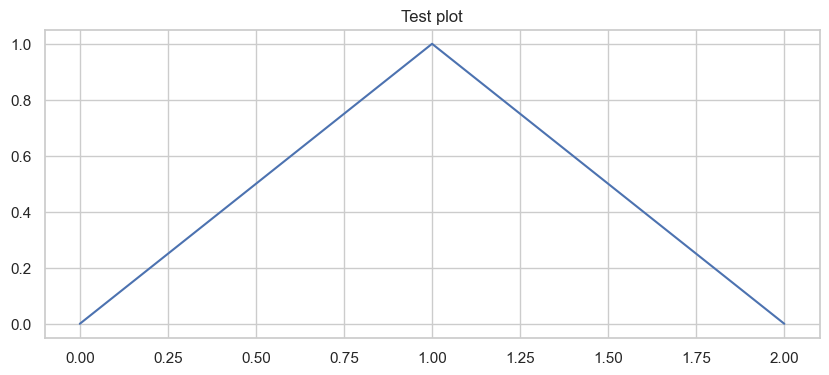

In [11]:
import matplotlib, matplotlib.pyplot as plt
print("matplotlib backend:", matplotlib.get_backend())
%matplotlib inline
plt.plot([0,1,2],[0,1,0])
plt.title("Test plot")
plt.show()

Running downstream demo with path: C:\esp32\csi\data\raw\yes_3.5.csv


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


(511637, 63)


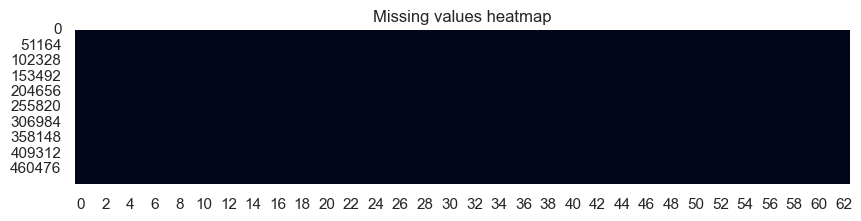

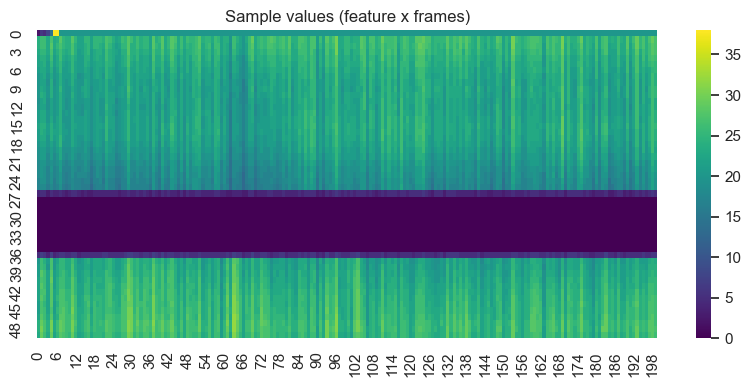

Loaded shape: (511637, 63)


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


explore_data: df type= <class 'pandas.DataFrame'>
explore_data: df.shape= (511637, 63)


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
count,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,...,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.000000,511637.00000,511637.000000
mean,19.998808,25.838149,25.630023,25.029150,24.387593,23.944003,23.449903,22.868014,22.462926,22.531602,...,22.488260,22.123169,22.438205,22.786579,23.072553,23.452479,23.914955,24.936199,25.87765,26.160375
std,0.289030,3.866589,3.912769,3.904734,3.915298,3.972884,4.008664,4.041653,4.149668,4.442563,...,4.130821,3.899228,3.817840,3.753988,3.680032,3.633310,3.621946,3.693170,3.78714,3.839208
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,20.000000,24.000000,24.000000,23.000000,22.000000,22.000000,21.000000,21.000000,20.000000,20.000000,...,20.000000,20.000000,20.000000,21.000000,21.000000,22.000000,22.000000,23.000000,24.00000,24.000000
50%,20.000000,26.000000,26.000000,25.000000,25.000000,24.000000,24.000000,23.000000,23.000000,23.000000,...,23.000000,22.000000,23.000000,23.000000,23.000000,24.000000,24.000000,25.000000,26.00000,26.000000
75%,20.000000,28.000000,28.000000,27.000000,27.000000,26.000000,26.000000,25.000000,25.000000,25.000000,...,25.000000,25.000000,25.000000,25.000000,25.000000,26.000000,26.000000,27.000000,28.00000,28.000000
max,38.000000,99.000000,101.000000,94.000000,92.000000,92.000000,89.000000,85.000000,88.000000,104.000000,...,86.000000,80.000000,84.000000,80.000000,81.000000,79.000000,85.000000,96.000000,94.00000,98.000000


Plotting hist for columns: [0, 1, 2, 3, 4, 5]


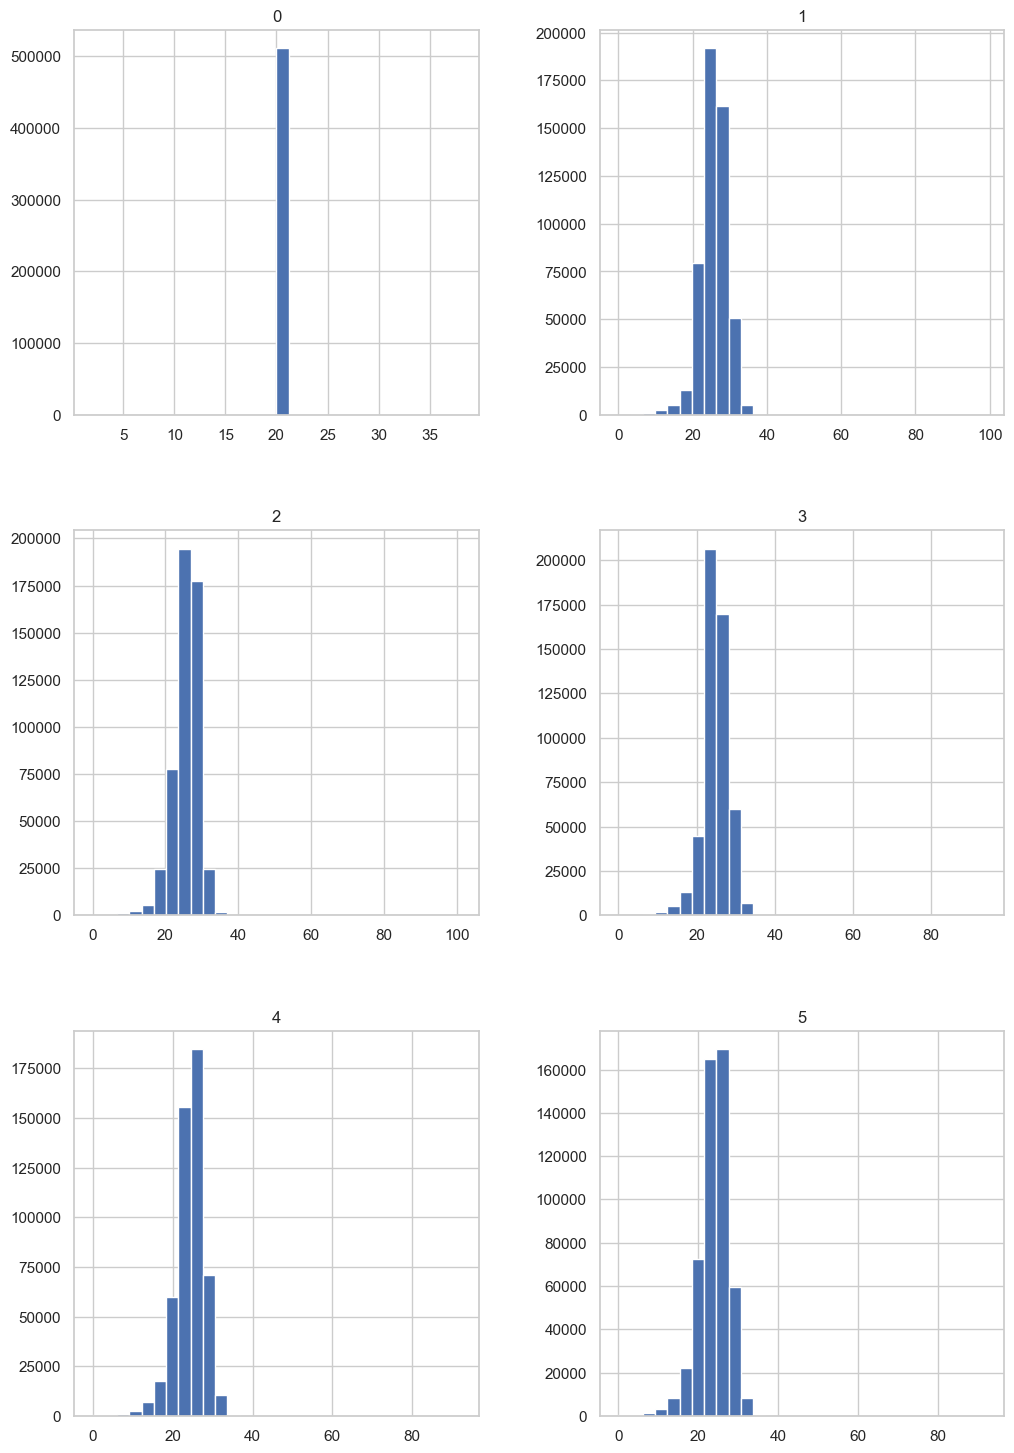

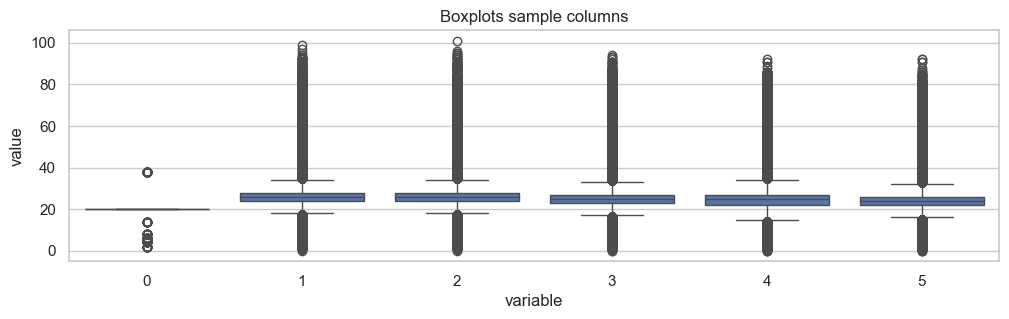

Numeric columns count: 63


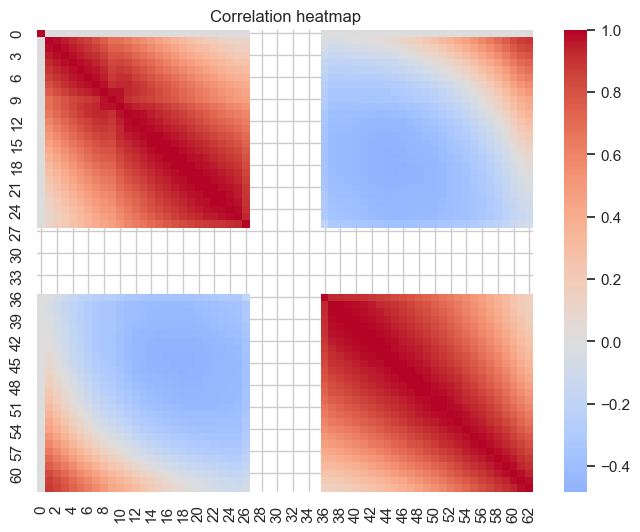

Missing before:
0     0
1     0
2     0
3     0
4     0
     ..
58    0
59    0
60    0
61    0
62    0
Length: 63, dtype: int64
Total missing before: 0
Missing after:
0     0
1     0
2     0
3     0
4     0
     ..
58    0
59    0
60    0
61    0
62    0
Length: 63, dtype: int64
Total missing after: 0
No missing values detected in the provided columns
No columns with missing values to plot
After impute_missing total missing: 0


,0,1,2,3,4,5,6,7,8,9,...,53,54,55,56,57,58,59,60,61,62
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,21.0,20.0,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,25.0,24.0,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,24.0,23.0,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,21.0,20.0,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,27.0,25.0,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0


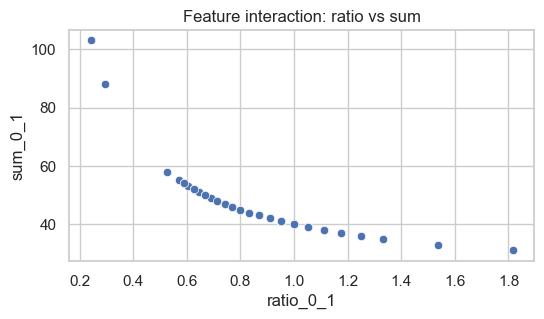

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,ratio_0_1,sum_0_1
0,2.0,24.0,24.0,23.0,22.0,22.0,21.0,20.0,20.0,20.0,...,20.0,20.0,20.0,20.0,21.0,23.0,24.0,24.0,0.083333,26.0
1,6.0,26.0,26.0,25.0,24.0,23.0,23.0,22.0,22.0,23.0,...,24.0,24.0,23.0,24.0,24.0,26.0,26.0,26.0,0.230769,32.0
2,5.0,26.0,26.0,25.0,24.0,24.0,23.0,23.0,22.0,22.0,...,23.0,23.0,22.0,23.0,23.0,25.0,26.0,26.0,0.192308,31.0
3,8.0,23.0,23.0,23.0,22.0,21.0,21.0,20.0,19.0,20.0,...,20.0,20.0,20.0,19.0,21.0,22.0,23.0,22.0,0.347826,31.0
4,14.0,27.0,28.0,27.0,26.0,25.0,24.0,23.0,24.0,24.0,...,25.0,25.0,24.0,25.0,25.0,27.0,27.0,27.0,0.518519,41.0


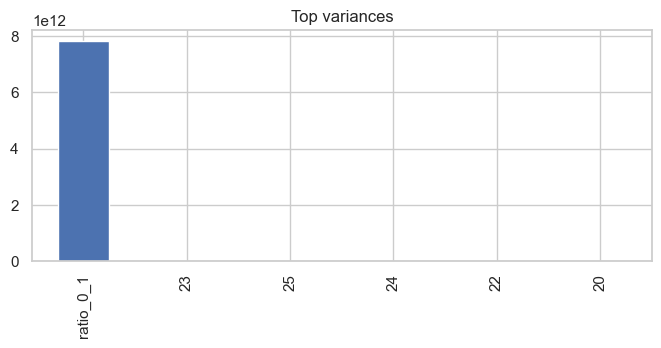

Selected features: ['ratio_0_1', 23, 25, 24, 22, 20]
Scaling cols: ['ratio_0_1', 23, 25, 24, 22, 20]
scale_features failed: Feature names are only supported if all input features have string names, but your input has ['int', 'str'] as feature name / column name types. If you want feature names to be stored and validated, you must convert them all to strings, by using X.columns = X.columns.astype(str) for example. Otherwise you can remove feature / column names from your input data, or convert them all to a non-string data type.
Saved pipeline to experiments\preprocessed\pipeline.joblib
Saved: experiments\preprocessed\train.csv experiments\preprocessed\test.csv
Downstream demo completed


In [17]:
# Run downstream demo: execute functions from this point downwards

def run_downstream_demo(path=None):
    from pathlib import Path
    import json

    # Auto-load definitions from this notebook if required
    if 'load_data' not in globals() or 'impute_missing' not in globals():
        nb_path = Path('src') / 'preprocess.ipynb'
        if not nb_path.exists():
            print('Notebook file not found to auto-load definitions:', nb_path)
        else:
            try:
                with nb_path.open('r', encoding='utf-8') as f:
                    nb = json.load(f)
                for cell in nb.get('cells', []):
                    if cell.get('cell_type') != 'code':
                        continue
                    src = ''.join(cell.get('source', []))
                    # Stop before re-running this runner cell
                    if 'def run_downstream_demo' in src or 'run_downstream_demo()' in src:
                        break
                    try:
                        exec(compile(src, '<notebook_cell>', 'exec'), globals())
                    except Exception as e:
                        # continue loading other cells even if one fails
                        print('Warning: exec cell failed:', e)
            except Exception as e:
                print('Could not auto-load definitions:', e)

    # fallback to SAMPLE_PATH or example test file
    if path is None:
        path = globals().get('SAMPLE_PATH') or "data/raw/walk.csv"
    print("Running downstream demo with path:", path)

    from pathlib import Path as _P
    if not _P(path).exists():
        print("Path not found:", path)
        return

    try:
        df = load_data(path)
        print('Loaded shape:', getattr(df, 'shape', None))
        display(df.head())
    except Exception as e:
        print('load_data failed:', e)
        return

    try:
        explore_data(df)
    except Exception as e:
        print('explore_data failed:', e)

    try:
        df2 = impute_missing(df, strategy='mean')
        print('After impute_missing total missing:', int(df2.isnull().sum().sum()))
        display(df2.head())
    except Exception as e:
        print('impute_missing failed:', e)
        df2 = df

    try:
        df3 = feature_engineering(df2)
        display(df3.head())
    except Exception as e:
        print('feature_engineering failed:', e)
        df3 = df2

    try:
        numcols = df3.select_dtypes(include=[np.number]).shape[1]
        k = min(6, numcols) if numcols > 0 else 0
        sel = select_features(df3, method='variance', k=k) if k > 0 else []
        print('Selected features:', sel)
    except Exception as e:
        print('select_features failed:', e)
        sel = []

    try:
        if sel:
            scaled, scaler = scale_features(df3, cols=sel, method='standard')
            display(scaled.head())
        else:
            scaled, scaler = df3, None
    except Exception as e:
        print('scale_features failed:', e)
        scaled, scaler = df3, None

    try:
        save_pipeline({'scaler':scaler}, 'experiments/preprocessed/pipeline.joblib')
    except Exception as e:
        print('save_pipeline failed:', e)

    try:
        split_and_save(scaled)
    except Exception as e:
        print('split_and_save failed:', e)

    print('Downstream demo completed')

# Run automatically when this cell is executed
run_downstream_demo()